This notebook provides supplementary implementation and extended analysis.

Key highlights:
- Outlier handling: compare model performance under three different scenarios.
- Feature selection: mitigate multicollinearity and explore different feature sets.
- Comprehensive model performance report and visual comparison of accuracy for each feature combination.
- Cross-validation to assess model stability.
- Includes error analysis, limitations, and insights for future work.

In this notebook,my work covered the following sections of the report:

2. Data description
3. EDA & preprocessing
4. Baseline model ： LogicRegression
5. Models & training : LogicRegression DecisionTree and Random Forest
6. Validation: K-fold cross validation
7. Evaluation: accuracy/F1/recall/precision/confusion-matrix/classification report
8. Results: This study provides a comprehensive model performance report for each feature combination, along with a visual comparison chart of model accuracy.
9. Error analysis & insights :
    + When I first performed data preprocessing, I handled outliers before applying normalization. The resulting data was used for model training.
        + Through observation, I first removed a data point with extreme outliers (where all three feature values u, g, and z were -9999). Next, I used the IQR method to eliminate outliers from the feature columns. Finally, I performed normalization processing.
    + The results show that the logistic regression achieved an accuracy of 0.59 and the confusion matrix showed that all test samples were classified as GALAXY, while the decision tree achieved an accuracy of 0.43.
    + The poor performance of this model is not due to the model itself, it is due to the data. This is because the preprocessing pipeline excessively removed outliers and then performed normalization on the resulting data.
    + This leads to a significant distortion in the data distribution and reduced inter-class differences, making it difficult for both linear and tree-based models to effectively distinguish between the three types of celestial bodies.
10. Limitations & future work :
    + There is no explanation for why the model's performance decreased after removing extreme outliers (where all three feature values u, g, and z were -9999).
    + The current outlier handling approach does not filter and delete data based on the number of outliers in a single record; instead, it deletes them directly.
    + Future work will further investigate the impact of extreme outliers on results and explore more granular handling of outliers.


+ obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
+ alpha = Right Ascension angle (at J2000 epoch)
+ delta = Declination angle (at J2000 epoch)
+ u = Ultraviolet filter in the photometric system
+ g = Green filter in the photometric system
+ r = Red filter in the photometric system
+ i = Near Infrared filter in the photometric system
+ z = Infrared filter in the photometric system
+ run_ID = Run Number used to identify the specific scan
+ rereun_ID = Rerun Number to specify how the image was processed
+ cam_col = Camera column to identify the scanline within the run
+ field_ID = Field number to identify each field
+ spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
+ class = object class (galaxy, star or quasar object)
+ redshift = redshift value based on the increase in wavelength
+ plate = plate ID, identifies each plate in SDSS
+ MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
+ fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings

warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("../data/star_classification.csv")
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [ ]:
df.shape

(100000, 18)

In [ ]:
# Check for duplicates based on spec_obj_ID
df['spec_obj_ID'].duplicated().sum()

np.int64(0)

In [ ]:
# Check whether the feature is a classification feature that requires one-hot encoding.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [ ]:
# Based on the metadata, select the columns to be dropped.
drop_col=['obj_ID', 'run_ID','rerun_ID', 'cam_col','field_ID', 'spec_obj_ID','plate', 'MJD','fiber_ID']
df=df.drop(columns=drop_col)

<Axes: xlabel='class', ylabel='count'>

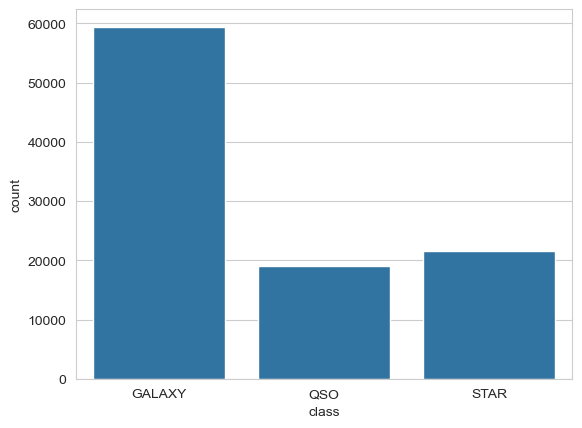

In [ ]:
# check the distribution of the target variable
sns.countplot(data=df, x='class')

In [ ]:
num_df = df.select_dtypes(include=['number'])

<Axes: >

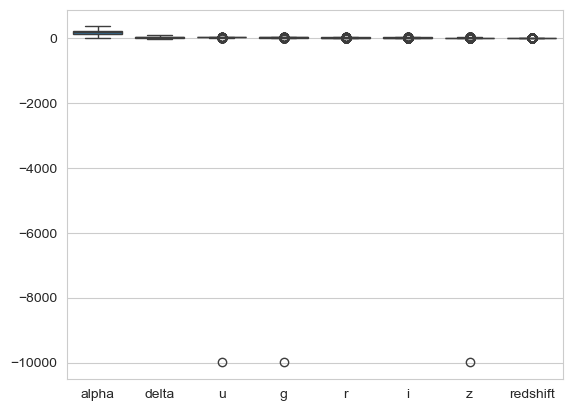

In [ ]:
#We can clearly see that several extreme outliers are affecting the box plot's presentation. They belong to u, g, and z.
sns.boxplot(data=num_df)

In [ ]:
# First, handle extreme outliers (ultimately opting to retain them).
top10_u=num_df['u'].nsmallest(10).tolist()
top10_g=num_df['g'].nsmallest(10).tolist()
top10_z=num_df['z'].nsmallest(10).tolist()

print("Top 10 smallest u values:\n", top10_u)
print("Top 10 smallest g values:\n", top10_g)
print("Top 10 smallest z values:\n", top10_z)

Top 10 smallest u values:
 [-9999.0, 10.99623, 12.10168, 12.2624, 12.30349, 12.99664, 13.89799, 13.94716, 14.14713, 14.15199]
Top 10 smallest g values:
 [-9999.0, 10.4982, 10.51139, 10.6718, 10.73097, 11.33897, 11.39234, 11.47435, 11.74518, 11.79892]
Top 10 smallest z values:
 [-9999.0, 9.612333, 10.22551, 10.44131, 10.65056, 10.77889, 10.89738, 10.91847, 11.19448, 11.30247]


In [ ]:
# remove extreme outliers （not remove）
mask=(num_df['u']==-9999) | (num_df['g']==-9999) | (num_df['z']==-9999)
# 79543
drop_index=num_df[mask].index
drop_index
# num_df.drop(index=drop_index,inplace=True)

Index([79543], dtype='int64')

In [ ]:
# Check feature dimensions
stats = pd.DataFrame({
    'min': num_df.min(),
    'max': num_df.max(),
    'std': num_df.std(),
    'range': num_df.max() - num_df.min()
})
stats

,min,max,std,range
alpha,0.005528,359.999810,96.502241,359.994282
delta,-18.785328,83.000519,19.644665,101.785847
u,-9999.000000,32.781390,31.769291,10031.781390
g,-9999.000000,31.602240,31.750292,10030.602240
r,9.822070,29.571860,1.854760,19.749790
i,9.469903,32.141470,1.757895,22.671567
z,-9999.000000,29.383740,31.728152,10028.383740
redshift,-0.009971,7.011245,0.730707,7.021216


In [ ]:
# normalization
scaler = MinMaxScaler()
norm_ndarry = scaler.fit_transform(num_df)
num_df=pd.DataFrame(norm_ndarry,columns=num_df.columns)
num_df.head()

,alpha,delta,u,g,r,i,z,redshift
0,0.376905,0.503802,0.999113,0.999070,0.535344,0.427665,0.998944,0.091831
1,0.402286,0.491812,0.999202,0.999126,0.646203,0.515986,0.999225,0.112389
2,0.394960,0.534139,0.999251,0.999109,0.546218,0.435729,0.998959,0.093170
3,0.940947,0.180600,0.998939,0.999220,0.596946,0.486717,0.998990,0.134210
4,0.959118,0.392679,0.998670,0.998602,0.337999,0.287021,0.998620,0.017959


<Axes: >

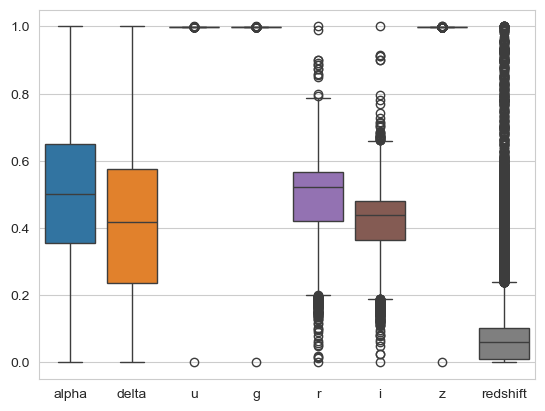

In [ ]:
sns.boxplot(data=num_df)

In [ ]:
# List the number of outliers and their proportion
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers

for col in num_df.columns:
    outliers = detect_outliers_iqr(num_df, col)
    print(f'Outliers for {col} are: {len(outliers)},proportion：{len(outliers)/len(num_df)*100 :.2f}%')

Outliers for alpha are: 0,proportion：0.00%
Outliers for delta are: 0,proportion：0.00%
Outliers for u are: 56,proportion：0.06%
Outliers for g are: 99,proportion：0.10%
Outliers for r are: 132,proportion：0.13%
Outliers for i are: 198,proportion：0.20%
Outliers for z are: 320,proportion：0.32%
Outliers for redshift are: 8990,proportion：8.99%


In [ ]:
# Handling Outliers Using the IQR Method
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    no_outliers_df = df[(df[col] >= lower) & (df[col] <= upper)]
    return no_outliers_df

In [ ]:
print(f'data counts before drop outliers: {len(num_df)}')
# for col in ['u','g','r','i','z','redshift']:
for col in ['u','g','r','i','z']:
    num_df=remove_outliers(num_df, col)
print(f'data counts after drop outliers: {len(num_df)}')

data counts before drop outliers: 100000
data counts after drop outliers: 99592


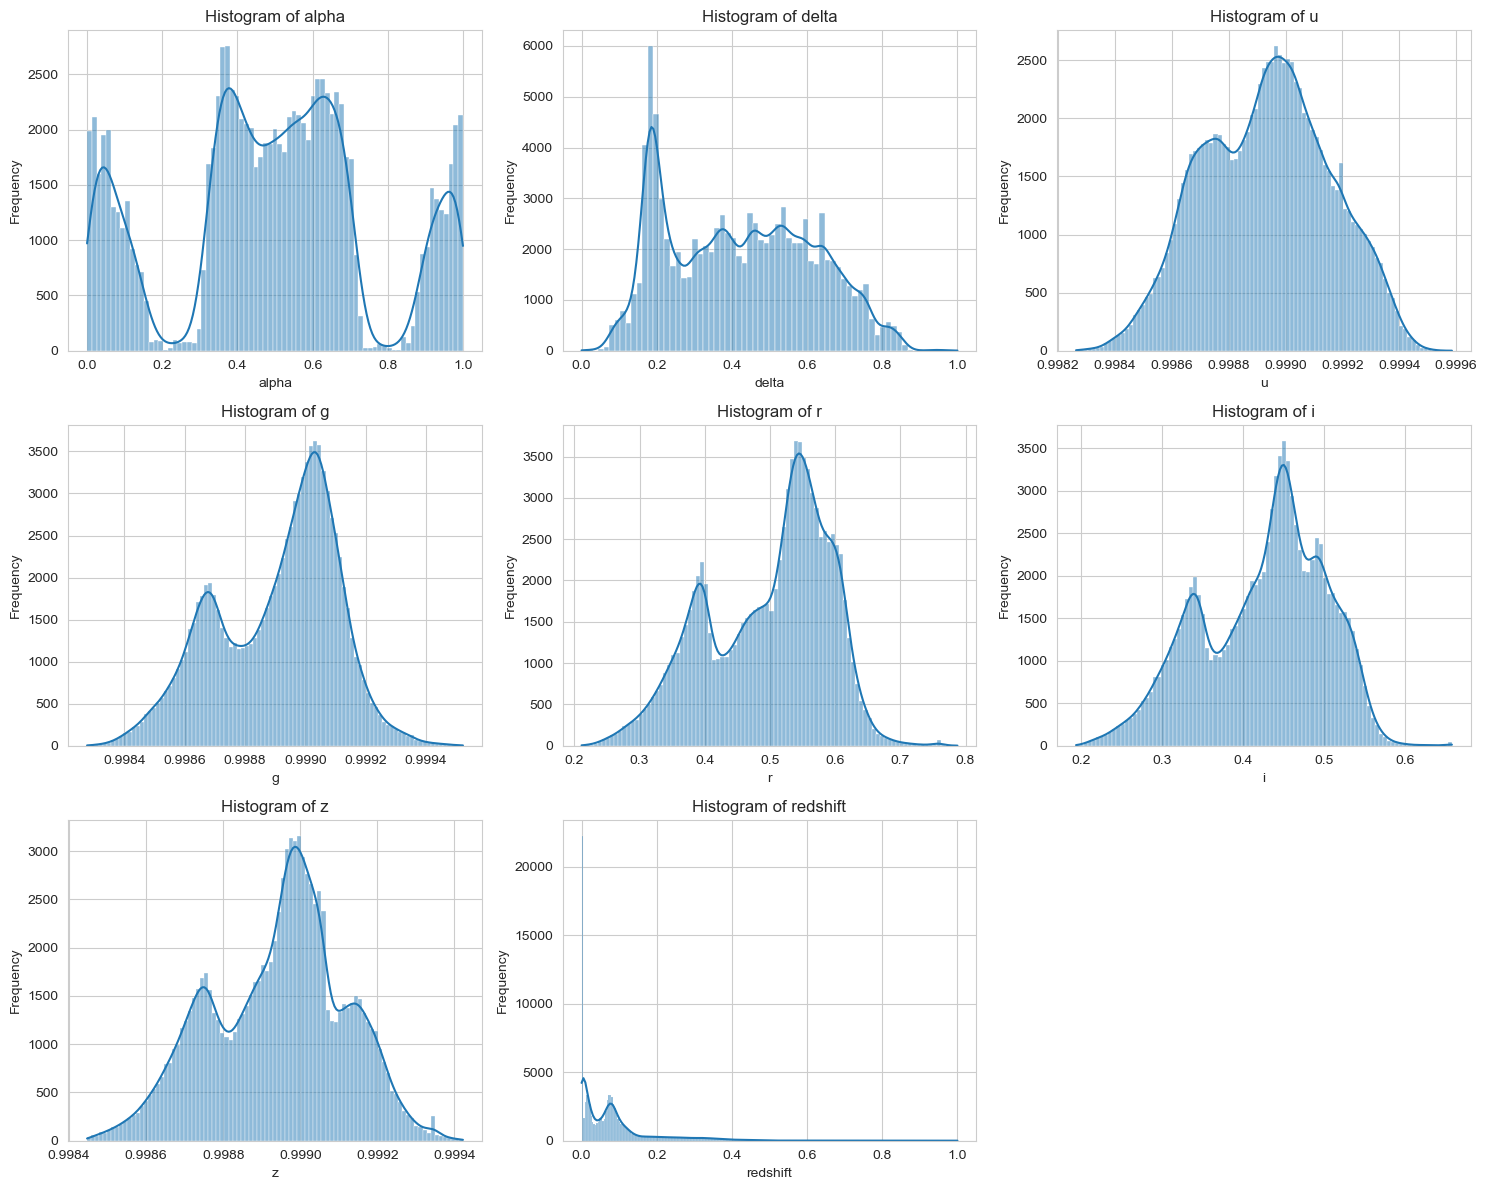

In [ ]:
# Use histograms to examine feature distributions
fig, axes = plt.subplots(3, 3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(num_df.columns):
    sns.histplot(num_df[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
# remove blank subplot
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: >

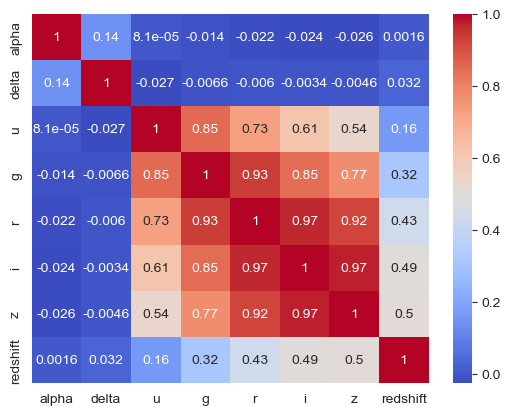

In [ ]:
# check corr_matrix
corr_matrix=num_df.corr()
# Multicollinearity exists among the features.
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")

In [ ]:
# retrieve class column
num_df['class']=df.loc[num_df.index,'class']

In [ ]:
num_df['class'].value_counts()

class
GALAXY    59155
STAR      21509
QSO       18928
Name: count, dtype: int64

In [ ]:
# Convert target variables into a numeric column
num_df['class'] = num_df['class'].map({'GALAXY': 0, 'STAR': 1, 'QSO': 2})

In [ ]:
num_df.head(10)

,alpha,delta,u,g,r,i,z,redshift,class
0,0.376905,0.503802,0.999113,0.999070,0.535344,0.427665,0.998944,0.091831,0
1,0.402286,0.491812,0.999202,0.999126,0.646203,0.515986,0.999225,0.112389,0
2,0.394960,0.534139,0.999251,0.999109,0.546218,0.435729,0.998959,0.093170,0
3,0.940947,0.180600,0.998939,0.999220,0.596946,0.486717,0.998990,0.134210,0
4,0.959118,0.392679,0.998670,0.998602,0.337999,0.287021,0.998620,0.017959,0
5,0.947208,0.386840,0.999074,0.999176,0.582279,0.475761,0.999019,0.204328,2
6,0.064527,0.296736,0.998872,0.998961,0.562346,0.491292,0.999107,0.084946,2
7,0.015077,0.303092,0.998950,0.999045,0.532623,0.441877,0.998950,0.069358,0
8,0.556356,0.648270,0.999165,0.999078,0.546246,0.440860,0.998960,0.095423,0
9,0.108736,0.460655,0.998900,0.998847,0.473598,0.412337,0.998930,0.001419,1


In [ ]:
# Output results as CSV
data_with_8feature=num_df
data_with_8feature.to_csv('../data/data_with_8feature.csv',index=False)
data_with_8feature.head()

,alpha,delta,u,g,r,i,z,redshift,class
0,0.376905,0.503802,0.999113,0.999070,0.535344,0.427665,0.998944,0.091831,0
1,0.402286,0.491812,0.999202,0.999126,0.646203,0.515986,0.999225,0.112389,0
2,0.394960,0.534139,0.999251,0.999109,0.546218,0.435729,0.998959,0.093170,0
3,0.940947,0.180600,0.998939,0.999220,0.596946,0.486717,0.998990,0.134210,0
4,0.959118,0.392679,0.998670,0.998602,0.337999,0.287021,0.998620,0.017959,0


In [ ]:
# remove alpha and delta columns
data_with_6feature=num_df.drop(columns=['alpha','delta'])
data_with_6feature.to_csv('../data/data_with_6feature.csv',index=False)
data_with_6feature.head()

,u,g,r,i,z,redshift,class
0,0.999113,0.999070,0.535344,0.427665,0.998944,0.091831,0
1,0.999202,0.999126,0.646203,0.515986,0.999225,0.112389,0
2,0.999251,0.999109,0.546218,0.435729,0.998959,0.093170,0
3,0.998939,0.999220,0.596946,0.486717,0.998990,0.134210,0
4,0.998670,0.998602,0.337999,0.287021,0.998620,0.017959,0


In [ ]:
#remove i and r
data_without_ir=num_df.drop(columns=['i','r'])
data_without_ir.to_csv('../data/data_without_ir.csv',index=False)
data_without_ir.head()

,alpha,delta,u,g,z,redshift,class
0,0.376905,0.503802,0.999113,0.999070,0.998944,0.091831,0
1,0.402286,0.491812,0.999202,0.999126,0.999225,0.112389,0
2,0.394960,0.534139,0.999251,0.999109,0.998959,0.093170,0
3,0.940947,0.180600,0.998939,0.999220,0.998990,0.134210,0
4,0.959118,0.392679,0.998670,0.998602,0.998620,0.017959,0


# After adjusting the order of normalization and outlier removal:

In [ ]:
print("After adjusting the order of normalization and outlier removal:")
baseline = {
    "Logistic Regression": 0.59,
    "Decision Tree": 0.43,
}
new_scores = {
    "Logistic Regression": 0.919673,
    "Decision Tree": 0.966095,
}
point_increase = {
    model: round((new_scores[model] - baseline[model]) * 100,1)
    for model in baseline
}
percent_increase = {
    model: round(((new_scores[model] - baseline[model]) / baseline[model]) * 100,1)
    for model in baseline
}
df = pd.DataFrame({
    "Model": baseline.keys(),
    "Before": baseline.values(),
    "After": new_scores.values(),
    "Point Increase": point_increase.values(),
    "Percent Increase": [f"{v}%" for v in percent_increase.values()]
})
df

After adjusting the order of normalization and outlier removal:


,Model,Before,After,Point Increase,Percent Increase
0,Logistic Regression,0.59,0.919673,33.0,55.9%
1,Decision Tree,0.43,0.966095,53.6,124.7%


# After drop extreme outlier:

In [ ]:
print("After drop extreme outlier:")
baseline = {
    "Logistic Regression": 0.919673,
    "Decision Tree": 0.966095,
    "Random Forest": 0.978646
}
new_scores = {
    "Logistic Regression": 0.792623,
    "Decision Tree": 0.805911,
    "Random Forest": 0.890455
}
point_increase = {
    model: round((new_scores[model] - baseline[model]) * 100,1)
    for model in baseline
}
percent_increase = {
    model: round(((new_scores[model] - baseline[model]) / baseline[model]) * 100,1)
    for model in baseline
}
df = pd.DataFrame({
    "Model": baseline.keys(),
    "Before": baseline.values(),
    "After": new_scores.values(),
    "Point Increase": point_increase.values(),
    "Percent Increase": [f"{v}%" for v in percent_increase.values()]
})
df

After drop extreme outlier:


,Model,Before,After,Point Increase,Percent Increase
0,Logistic Regression,0.919673,0.792623,-12.7,-13.8%
1,Decision Tree,0.966095,0.805911,-16.0,-16.6%
2,Random Forest,0.978646,0.890455,-8.8,-9.0%


# Comparation between baseline and My model

In [ ]:
print("Comparation between baseline and My model")
baseline = {
    "Logistic Regression": 0.910640,
    "Decision Tree": 0.958675,
    "Random Forest": 0.958675
}
new_scores = {
    "Logistic Regression": 0.919673,
    "Decision Tree": 0.966095,
    "Random Forest": 0.978646
}
point_increase = {
    model: round((new_scores[model] - baseline[model]) * 100,1)
    for model in baseline
}
percent_increase = {
    model: round(((new_scores[model] - baseline[model]) / baseline[model]) * 100,1)
    for model in baseline
}
df = pd.DataFrame({
    "Model": baseline.keys(),
    "Before": baseline.values(),
    "After": new_scores.values(),
    "Point Increase": point_increase.values(),
    "Percent Increase": [f"{v}%" for v in percent_increase.values()]
})
df

Comparation between baseline and My model


,Model,Before,After,Point Increase,Percent Increase
0,Logistic Regression,0.910640,0.919673,0.9,1.0%
1,Decision Tree,0.958675,0.966095,0.7,0.8%
2,Random Forest,0.958675,0.978646,2.0,2.1%


# Training Model -   LogisticRegression, DecisionTreeClassifier

In [ ]:
# choose data with different feature
#data_without_ir ： LR：0.9054635761589404 DT：0.9570640176600441/0.9559602649006622
#data_with_8feature: LR: 0.9204194260485651 DT: 0.9605960264900663/0.9608167770419426
#data_with_6feature LR: 0.9178256070640176 DT: 0.959878587196468/0.9604304635761589
# dont remove redshift outliers: LR:0.9250483291908312 DT:0.9611709472521403
def train_eval_model(model, data,target='class', test_size=0.3):
    X = data.drop(columns=target)
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,random_state=42)

    # use k-fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    print(f"{model.__class__.__name__}:\nCross-validation scores:", cv_scores)
    print("Mean CV accuracy:", cv_scores.mean())

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    #evaluate
    accuracy=accuracy_score(y_test, y_pred)
    f1= f1_score(y_test, y_pred, average= 'weighted')
    confusion = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print('='*99)
    print(f'{model.__class__.__name__}:\nbase on {len(X.columns)} features: {list(X.columns)} ')
    print(f'Accuracy: {accuracy}')
    print(f'F1-score: {f1}')
    print(f'Confusion matrix:\n{confusion}')
    # print(f'Report on confusion matrix:\n{report}')
    print('='*99)
    return accuracy

In [ ]:

datasets = [data_with_8feature, data_with_6feature, data_without_ir]
dataset_names = ["8 features", "6 features", "without IR"]
models = [LogisticRegression(), DecisionTreeClassifier(),RandomForestClassifier()]
model_names = ["Logistic Regression (BaseLine)", "Decision Tree", "Random Forest"]


records = []

for data, dname in zip(datasets, dataset_names):
    for model, mname in zip(models, model_names):
        # train and get evaluate report
        acc = train_eval_model(model, data)
        records.append([dname, mname, acc])

df_results = pd.DataFrame(records, columns=["Feature Set", "Model", "Accuracy"])
print(df_results)


LogisticRegression:
Cross-validation scores: [0.92469339 0.91106648 0.92433479 0.9180951  0.92504662]
Mean CV accuracy: 0.9206472788728641
LogisticRegression:
base on 8 features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift'] 
Accuracy: 0.9196733382421849
F1-score: 0.9190604917517234
Confusion matrix:
[[16959   577   179]
 [  686  5861     0]
 [  943    15  4658]]
DecisionTreeClassifier:
Cross-validation scores: [0.96629133 0.96249014 0.9647852  0.96041024 0.96327643]
Mean CV accuracy: 0.9634506673804909
DecisionTreeClassifier:
base on 8 features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift'] 
Accuracy: 0.9668317825825021
F1-score: 0.9668958396497572
Confusion matrix:
[[17186    24   505]
 [   24  6522     1]
 [  436     1  5179]]
RandomForestClassifier:
Cross-validation scores: [0.97898587 0.97554328 0.97934447 0.97661909 0.97747812]
Mean CV accuracy: 0.9775941688033228
RandomForestClassifier:
base on 8 features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift

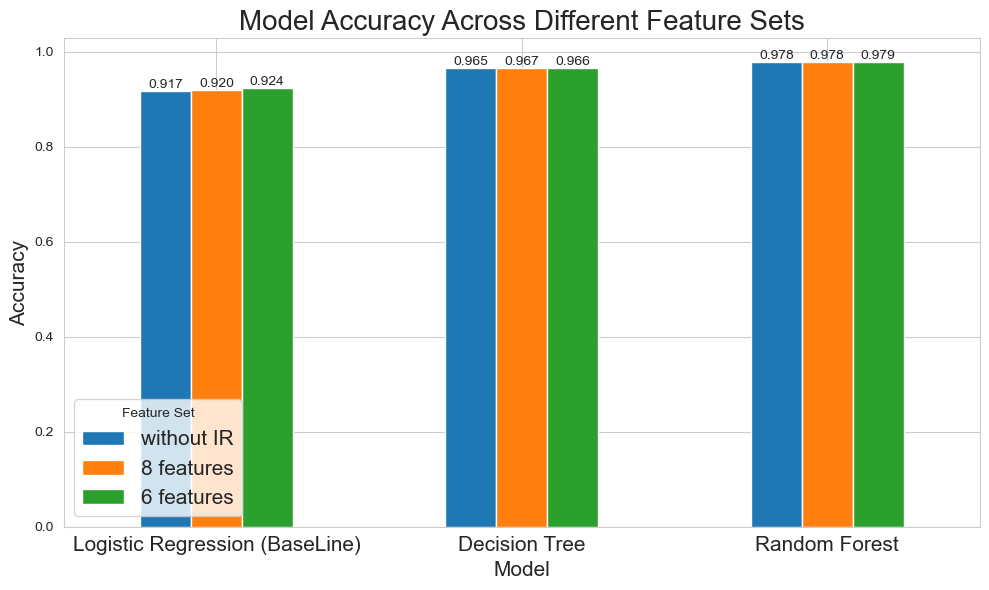

In [ ]:
# visualization compare different feature sets
df_plot = df_results.pivot(index="Model", columns="Feature Set", values="Accuracy")

desired_order = model_names
model_order = model_names
feature_order = ["without IR", "8 features", "6 features", ]
df_plot = df_plot.reindex(index=model_order, columns=feature_order)

ax=df_plot.plot(kind="bar", figsize=(10,6))
plt.title("Model Accuracy Across Different Feature Sets",fontsize=20)
plt.ylabel("Accuracy",fontsize=15)
plt.xlabel("Model",fontsize=15)
plt.xticks(rotation=0,fontsize=15)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.3f}",(p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)
plt.legend(title="Feature Set",fontsize=15)
plt.tight_layout()
plt.show()